# Titanic Preprocessing and Modeling

This notebook downloads the Titanic competition data, performs quick exploratory data analysis, prepares the features with an sklearn preprocessing pipeline, and trains a simple baseline classifier.

## 1. Imports

In [1]:
print(5)

5


In [3]:
from pathlib import Path
import os

import kagglehub
from kagglehub.config import set_kaggle_api_token

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import skore
import wandb
from optuna.integration import WeightsAndBiasesCallback
from dotenv import load_dotenv
load_dotenv()

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
wandb.login(key=os.environ["WANDB_API_KEY"])
set_kaggle_api_token(os.environ["KAGGLE_KEY"])

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/saad/.netrc


wandb: Currently logged in as: saadaltohamy (saadaltohamy-wfrley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Kaggle credentials set.


## 2. Load the dataset

In [5]:
data_dir = "/mnt/d/Programming/ITI/MLOps/Labs/mlops-lab0/data/raw"
competition_path = Path(kagglehub.competition_download("titanic", output_dir=data_dir, force_download=True))


def find_csv(root: Path, file_name: str) -> Path:
    matches = list(root.rglob(file_name))
    if not matches:
        raise FileNotFoundError(f"Could not find {file_name} under {root}")
    return matches[0]


train_path = find_csv(competition_path, "train.csv")
test_path = find_csv(competition_path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Competition files stored in: {competition_path}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

100%|██████████| 34.1k/34.1k [00:00<00:00, 372kB/s]

Extracting files...


Competition files stored in: /mnt/d/Programming/ITI/MLOps/Labs/mlops-lab0/data/raw
Train shape: (891, 12)
Test shape: (418, 11)


## 3. Quick EDA

In [6]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
display(train_df.info())
display(train_df.describe(include="all").T)
display(train_df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


,missing_values
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [8]:
train_df.nunique().sort_values()

Survived         2
Sex              2
Pclass           3
Embarked         3
Parch            7
SibSp            7
Age             88
Cabin          147
Fare           248
Ticket         681
PassengerId    891
Name           891
dtype: int64

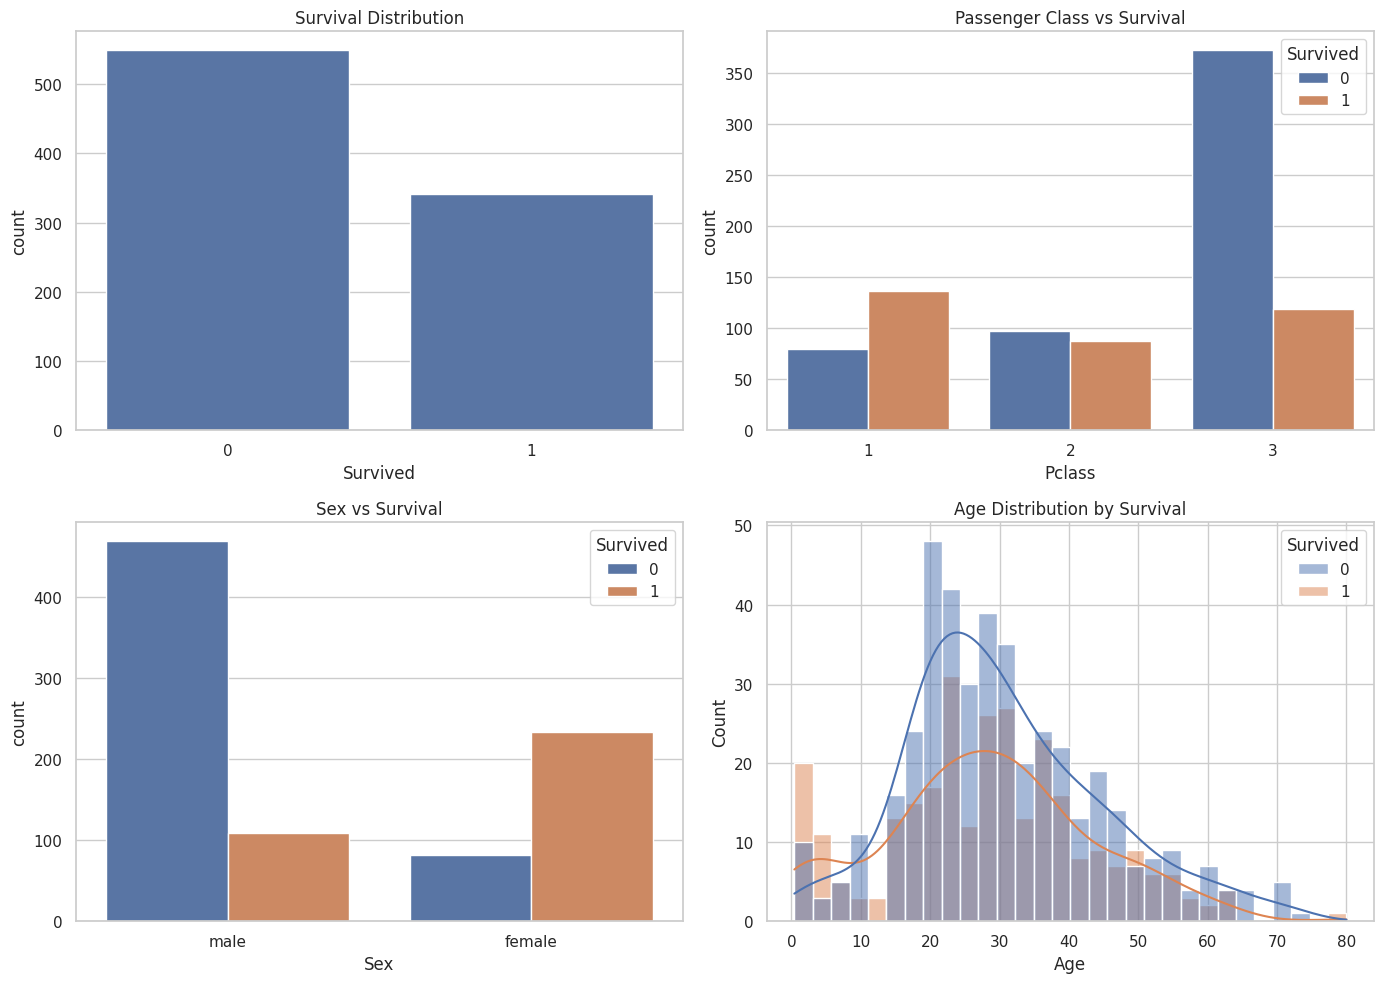

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=train_df, x="Survived", ax=axes[0, 0])
axes[0, 0].set_title("Survival Distribution")

sns.countplot(data=train_df, x="Pclass", hue="Survived", ax=axes[0, 1])
axes[0, 1].set_title("Passenger Class vs Survival")

sns.countplot(data=train_df, x="Sex", hue="Survived", ax=axes[1, 0])
axes[1, 0].set_title("Sex vs Survival")

sns.histplot(data=train_df, x="Age", hue="Survived", kde=True, bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Age Distribution by Survival")

plt.tight_layout()

In [10]:
train_df.select_dtypes(include=["number"]).drop(["PassengerId","Survived"], axis=1).columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [11]:
train_df.select_dtypes(include=["str"]).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')

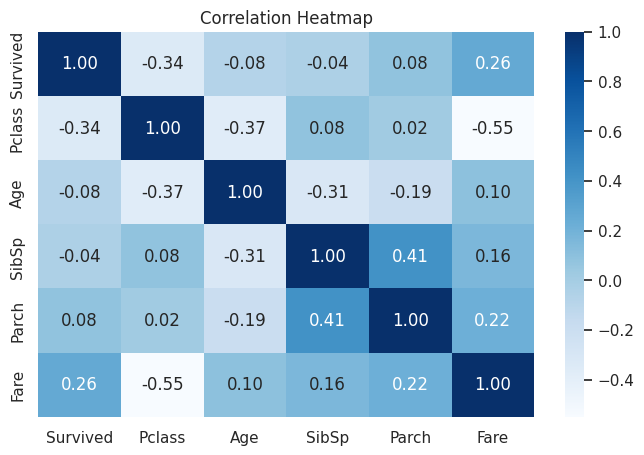

In [12]:
numeric_eda_cols = train_df.select_dtypes(include=["number"]).drop("PassengerId", axis=1).columns
corr = train_df[numeric_eda_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 4. Pre-processing with sklearn Pipeline

In [13]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [14]:
dropped_cols = ["Cabin",
                "PassengerId",
                "Ticket",
                "Name",
                "Survived"]

target_column = "Survived"

X = train_df.drop(dropped_cols, axis=1).copy()
y = train_df[target_column].copy()
X_test_competition = test_df.drop(dropped_cols[:-1], axis=1).copy()

numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_onehot_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

categorical_ordinal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1,
            ),
        ),
    ]
)

onehot_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_onehot_transformer, categorical_features),
    ]
)

hist_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_ordinal_transformer, categorical_features),
    ]
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_valid.shape

((712, 7), (179, 7))

In [15]:
transformed_sample = onehot_preprocessor.fit_transform(X_train)
print("Transformed feature matrix shape:", transformed_sample.shape)

Transformed feature matrix shape: (712, 12)


## 5. Optuna Model Search

In [16]:
try:
    import optuna
    from catboost import CatBoostClassifier
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "Install optuna, xgboost, and catboost before running the optimization section."
    ) from exc

MODEL_NAMES = [
    "random_forest",
    "extra_trees",
    "gradient_boosting",
    "hist_gradient_boosting",
    "xgboost",
    "catboost",
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
hist_categorical_feature_idx = list(
    range(len(numeric_features), len(numeric_features) + len(categorical_features))
)


def prepare_catboost_frame(frame: pd.DataFrame) -> pd.DataFrame:
    prepared = frame.copy()
    for column in categorical_features:
        prepared[column] = prepared[column].fillna("missing").astype(str)
    return prepared


X_train_catboost = prepare_catboost_frame(X_train)
X_valid_catboost = prepare_catboost_frame(X_valid)
X_test_catboost = prepare_catboost_frame(X_test_competition)


def sample_model_params(trial: optuna.Trial) -> dict:
    model_name = trial.suggest_categorical("model_name", MODEL_NAMES)
    params = {"model_name": model_name}

    if model_name == "random_forest":
        params.update(
            {
                "n_estimators": trial.suggest_int("rf_n_estimators", 200, 700),
                "max_depth": trial.suggest_int("rf_max_depth", 3, 16),
                "min_samples_split": trial.suggest_int("rf_min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("rf_min_samples_leaf", 1, 10),
                "max_features": trial.suggest_categorical(
                    "rf_max_features", ["sqrt", "log2", None]
                ),
            }
        )
    elif model_name == "extra_trees":
        params.update(
            {
                "n_estimators": trial.suggest_int("et_n_estimators", 200, 700),
                "max_depth": trial.suggest_int("et_max_depth", 3, 16),
                "min_samples_split": trial.suggest_int("et_min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("et_min_samples_leaf", 1, 10),
                "max_features": trial.suggest_categorical(
                    "et_max_features", ["sqrt", "log2", None]
                ),
            }
        )
    elif model_name == "gradient_boosting":
        params.update(
            {
                "n_estimators": trial.suggest_int("gb_n_estimators", 100, 500),
                "learning_rate": trial.suggest_float("gb_learning_rate", 0.01, 0.2, log=True),
                "max_depth": trial.suggest_int("gb_max_depth", 2, 6),
                "min_samples_split": trial.suggest_int("gb_min_samples_split", 2, 20),
                "min_samples_leaf": trial.suggest_int("gb_min_samples_leaf", 1, 10),
                "subsample": trial.suggest_float("gb_subsample", 0.6, 1.0),
                "max_features": trial.suggest_categorical(
                    "gb_max_features", ["sqrt", "log2", None]
                ),
            }
        )
    elif model_name == "hist_gradient_boosting":
        params.update(
            {
                "learning_rate": trial.suggest_float("hgb_learning_rate", 0.01, 0.2, log=True),
                "max_iter": trial.suggest_int("hgb_max_iter", 150, 600),
                "max_leaf_nodes": trial.suggest_int("hgb_max_leaf_nodes", 15, 63),
                "max_depth": trial.suggest_int("hgb_max_depth", 3, 12),
                "min_samples_leaf": trial.suggest_int("hgb_min_samples_leaf", 10, 60),
                "l2_regularization": trial.suggest_float(
                    "hgb_l2_regularization", 1e-4, 10.0, log=True
                ),
                "max_bins": trial.suggest_int("hgb_max_bins", 64, 255),
            }
        )
    elif model_name == "xgboost":
        params.update(
            {
                "n_estimators": trial.suggest_int("xgb_n_estimators", 150, 700),
                "learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.2, log=True),
                "max_depth": trial.suggest_int("xgb_max_depth", 3, 10),
                "min_child_weight": trial.suggest_float(
                    "xgb_min_child_weight", 1.0, 10.0
                ),
                "subsample": trial.suggest_float("xgb_subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float(
                    "xgb_colsample_bytree", 0.6, 1.0
                ),
                "reg_alpha": trial.suggest_float("xgb_reg_alpha", 1e-4, 10.0, log=True),
                "reg_lambda": trial.suggest_float("xgb_reg_lambda", 1e-4, 10.0, log=True),
            }
        )
    else:
        params.update(
            {
                "iterations": trial.suggest_int("cat_iterations", 200, 800),
                "learning_rate": trial.suggest_float(
                    "cat_learning_rate", 0.01, 0.2, log=True
                ),
                "depth": trial.suggest_int("cat_depth", 4, 10),
                "l2_leaf_reg": trial.suggest_float("cat_l2_leaf_reg", 1.0, 10.0),
                "random_strength": trial.suggest_float(
                    "cat_random_strength", 1e-3, 10.0, log=True
                ),
                "bagging_temperature": trial.suggest_float(
                    "cat_bagging_temperature", 0.0, 5.0
                ),
                "border_count": trial.suggest_int("cat_border_count", 32, 255),
            }
        )

    return params


def build_model_from_params(params: dict):
    model_name = params["model_name"]

    if model_name == "random_forest":
        estimator = Pipeline(
            steps=[
                ("preprocessor", onehot_preprocessor),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=params["n_estimators"],
                        max_depth=params["max_depth"],
                        min_samples_split=params["min_samples_split"],
                        min_samples_leaf=params["min_samples_leaf"],
                        max_features=params["max_features"],
                        class_weight="balanced",
                        n_jobs=-1,
                        random_state=42,
                    ),
                ),
            ]
        )
        return estimator, X_train, X_valid, X_test_competition, {}

    if model_name == "extra_trees":
        estimator = Pipeline(
            steps=[
                ("preprocessor", onehot_preprocessor),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=params["n_estimators"],
                        max_depth=params["max_depth"],
                        min_samples_split=params["min_samples_split"],
                        min_samples_leaf=params["min_samples_leaf"],
                        max_features=params["max_features"],
                        class_weight="balanced",
                        n_jobs=-1,
                        random_state=42,
                    ),
                ),
            ]
        )
        return estimator, X_train, X_valid, X_test_competition, {}

    if model_name == "gradient_boosting":
        estimator = Pipeline(
            steps=[
                ("preprocessor", onehot_preprocessor),
                (
                    "model",
                    GradientBoostingClassifier(
                        n_estimators=params["n_estimators"],
                        learning_rate=params["learning_rate"],
                        max_depth=params["max_depth"],
                        min_samples_split=params["min_samples_split"],
                        min_samples_leaf=params["min_samples_leaf"],
                        subsample=params["subsample"],
                        max_features=params["max_features"],
                        random_state=42,
                    ),
                ),
            ]
        )
        return estimator, X_train, X_valid, X_test_competition, {}

    if model_name == "hist_gradient_boosting":
        estimator = Pipeline(
            steps=[
                ("preprocessor", hist_preprocessor),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        learning_rate=params["learning_rate"],
                        max_iter=params["max_iter"],
                        max_leaf_nodes=params["max_leaf_nodes"],
                        max_depth=params["max_depth"],
                        min_samples_leaf=params["min_samples_leaf"],
                        l2_regularization=params["l2_regularization"],
                        max_bins=params["max_bins"],
                        categorical_features=hist_categorical_feature_idx,
                        early_stopping=False,
                        random_state=42,
                    ),
                ),
            ]
        )
        return estimator, X_train, X_valid, X_test_competition, {}

    if model_name == "xgboost":
        estimator = Pipeline(
            steps=[
                ("preprocessor", onehot_preprocessor),
                (
                    "model",
                    XGBClassifier(
                        n_estimators=params["n_estimators"],
                        learning_rate=params["learning_rate"],
                        max_depth=params["max_depth"],
                        min_child_weight=params["min_child_weight"],
                        subsample=params["subsample"],
                        colsample_bytree=params["colsample_bytree"],
                        reg_alpha=params["reg_alpha"],
                        reg_lambda=params["reg_lambda"],
                        scale_pos_weight=scale_pos_weight,
                        tree_method="hist",
                        eval_metric="logloss",
                        random_state=42,
                        n_jobs=-1,
                    ),
                ),
            ]
        )
        return estimator, X_train, X_valid, X_test_competition, {}

    estimator = CatBoostClassifier(
        iterations=params["iterations"],
        learning_rate=params["learning_rate"],
        depth=params["depth"],
        l2_leaf_reg=params["l2_leaf_reg"],
        random_strength=params["random_strength"],
        bagging_temperature=params["bagging_temperature"],
        border_count=params["border_count"],
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        verbose=0,
        allow_writing_files=False,
        random_state=42,
    )
    return estimator, X_train_catboost, X_valid_catboost, X_test_catboost, {
        "cat_features": categorical_features
    }


def objective(trial: optuna.Trial) -> float:
    params = sample_model_params(trial)
    estimator, search_train, _, _, fit_kwargs = build_model_from_params(params)

    fold_scores = []
    for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
        estimator_fold = clone(estimator)
        X_fold_train = search_train.iloc[train_idx]
        X_fold_valid = search_train.iloc[valid_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]

        estimator_fold.fit(X_fold_train, y_fold_train, **fit_kwargs)
        y_valid_proba = estimator_fold.predict_proba(X_fold_valid)[:, 1]
        fold_score = roc_auc_score(y_fold_valid, y_valid_proba)
        fold_scores.append(fold_score)

        trial.report(float(np.mean(fold_scores)), step=fold_idx)

    return float(np.mean(fold_scores))

## 6. Run Optimization

In [17]:
# Define the wandb callback for Optuna
wandb_callback = WeightsAndBiasesCallback(
    metric_name="roc_auc",
    as_multirun=True,
    wandb_kwargs={
        "project": os.getenv("WANDB_PROJECT"),
    },
)

/tmp/ipykernel_2230/2416589310.py:2: ExperimentalWarning: WeightsAndBiasesCallback is experimental (supported from v2.9.0). The interface can change in the future.
  wandb_callback = WeightsAndBiasesCallback(


In [18]:
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    study_name="titanic_tree_search",
    direction="maximize",
    sampler=sampler,
)

for model_name in MODEL_NAMES:
    study.enqueue_trial({"model_name": model_name})

n_trials = 10
study.optimize(
    objective,
    n_trials=n_trials,
    show_progress_bar=True,
    callbacks=[wandb_callback]
)
print(f"Best ROC AUC: {study.best_value:.4f}")
print(f"Best model: {study.best_trial.params['model_name']}")
study.best_trial.params

[I 2026-04-22 17:48:26,430] A new study created in memory with name: titanic_tree_search


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-22 17:48:30,909] Trial 0 finished with value: 0.8729771856495994 and parameters: {'model_name': 'random_forest', 'rf_n_estimators': 387, 'rf_max_depth': 16, 'rf_min_samples_split': 15, 'rf_min_samples_leaf': 6, 'rf_max_features': 'sqrt'}. Best is trial 0 with value: 0.8729771856495994.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


rf_max_depth,▁
rf_min_samples_leaf,▁
rf_min_samples_split,▁
rf_n_estimators,▁
roc_auc,▁
trial_number,▁
model_name,random_forest
rf_max_depth,16
rf_max_features,sqrt
rf_min_samples_leaf,6
rf_min_samples_split,15


[I 2026-04-22 17:49:13,795] Trial 1 finished with value: 0.8654025759158988 and parameters: {'model_name': 'extra_trees', 'et_n_estimators': 633, 'et_max_depth': 11, 'et_min_samples_split': 15, 'et_min_samples_leaf': 1, 'et_max_features': 'sqrt'}. Best is trial 0 with value: 0.8729771856495994.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


et_max_depth,▁
et_min_samples_leaf,▁
et_min_samples_split,▁
et_n_estimators,▁
roc_auc,▁
trial_number,▁
et_max_depth,11
et_max_features,sqrt
et_min_samples_leaf,1
et_min_samples_split,15
et_n_estimators,633


[I 2026-04-22 17:49:38,911] Trial 2 finished with value: 0.8750664560970204 and parameters: {'model_name': 'gradient_boosting', 'gb_n_estimators': 172, 'gb_learning_rate': 0.017322667470546258, 'gb_max_depth': 3, 'gb_min_samples_split': 11, 'gb_min_samples_leaf': 5, 'gb_subsample': 0.7164916560792167, 'gb_max_features': 'sqrt'}. Best is trial 2 with value: 0.8750664560970204.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


gb_learning_rate,▁
gb_max_depth,▁
gb_min_samples_leaf,▁
gb_min_samples_split,▁
gb_n_estimators,▁
gb_subsample,▁
roc_auc,▁
trial_number,▁
gb_learning_rate,0.01732
gb_max_depth,3
gb_max_features,sqrt


[I 2026-04-22 17:50:32,838] Trial 3 finished with value: 0.8674692721362 and parameters: {'model_name': 'hist_gradient_boosting', 'hgb_learning_rate': 0.029967309097101588, 'hgb_max_iter': 355, 'hgb_max_leaf_nodes': 53, 'hgb_max_depth': 4, 'hgb_min_samples_leaf': 36, 'hgb_l2_regularization': 0.09163741808778776, 'hgb_max_bins': 72}. Best is trial 2 with value: 0.8750664560970204.


hgb_l2_regularization,▁
hgb_learning_rate,▁
hgb_max_bins,▁
hgb_max_depth,▁
hgb_max_iter,▁
hgb_max_leaf_nodes,▁
hgb_min_samples_leaf,▁
roc_auc,▁
trial_number,▁
hgb_l2_regularization,0.09164
hgb_learning_rate,0.02997


[I 2026-04-22 17:51:15,922] Trial 4 finished with value: 0.8792375294216986 and parameters: {'model_name': 'xgboost', 'xgb_n_estimators': 484, 'xgb_learning_rate': 0.016666983286066417, 'xgb_max_depth': 3, 'xgb_min_child_weight': 9.539969835279999, 'xgb_subsample': 0.9862528132298237, 'xgb_colsample_bytree': 0.9233589392465844, 'xgb_reg_alpha': 0.0033347927286375843, 'xgb_reg_lambda': 0.0003078651783619622}. Best is trial 4 with value: 0.8792375294216986.


roc_auc,▁
trial_number,▁
xgb_colsample_bytree,▁
xgb_learning_rate,▁
xgb_max_depth,▁
xgb_min_child_weight,▁
xgb_n_estimators,▁
xgb_reg_alpha,▁
xgb_reg_lambda,▁
xgb_subsample,▁
model_name,xgboost


[I 2026-04-22 17:51:46,230] Trial 5 finished with value: 0.8821414510834573 and parameters: {'model_name': 'catboost', 'cat_iterations': 611, 'cat_learning_rate': 0.03738105868191797, 'cat_depth': 4, 'cat_l2_leaf_reg': 5.456592191001432, 'cat_random_strength': 0.0013726318898045872, 'cat_bagging_temperature': 4.546602010393911, 'cat_border_count': 89}. Best is trial 5 with value: 0.8821414510834573.


cat_bagging_temperature,▁
cat_border_count,▁
cat_depth,▁
cat_iterations,▁
cat_l2_leaf_reg,▁
cat_learning_rate,▁
cat_random_strength,▁
roc_auc,▁
trial_number,▁
cat_bagging_temperature,4.5466
cat_border_count,89


[I 2026-04-22 17:52:26,073] Trial 6 finished with value: 0.8612593806402584 and parameters: {'model_name': 'catboost', 'cat_iterations': 665, 'cat_learning_rate': 0.16684619386293467, 'cat_depth': 10, 'cat_l2_leaf_reg': 6.381099809299767, 'cat_random_strength': 4.869640941520899, 'cat_bagging_temperature': 0.4424625102595975, 'cat_border_count': 75}. Best is trial 5 with value: 0.8821414510834573.


cat_bagging_temperature,▁
cat_border_count,▁
cat_depth,▁
cat_iterations,▁
cat_l2_leaf_reg,▁
cat_learning_rate,▁
cat_random_strength,▁
roc_auc,▁
trial_number,▁
cat_bagging_temperature,0.44246
cat_border_count,75


[I 2026-04-22 17:52:46,738] Trial 7 finished with value: 0.8795078528228999 and parameters: {'model_name': 'xgboost', 'xgb_n_estimators': 304, 'xgb_learning_rate': 0.05082341959721458, 'xgb_max_depth': 4, 'xgb_min_child_weight': 8.219772826786357, 'xgb_subsample': 0.6298202574719083, 'xgb_colsample_bytree': 0.9947547746402069, 'xgb_reg_alpha': 0.7264803074826727, 'xgb_reg_lambda': 0.0009853225172032562}. Best is trial 5 with value: 0.8821414510834573.


roc_auc,▁
trial_number,▁
xgb_colsample_bytree,▁
xgb_learning_rate,▁
xgb_max_depth,▁
xgb_min_child_weight,▁
xgb_n_estimators,▁
xgb_reg_alpha,▁
xgb_reg_lambda,▁
xgb_subsample,▁
model_name,xgboost


[I 2026-04-22 17:53:18,041] Trial 8 finished with value: 0.8529115079742038 and parameters: {'model_name': 'extra_trees', 'et_n_estimators': 379, 'et_max_depth': 4, 'et_min_samples_split': 18, 'et_min_samples_leaf': 7, 'et_max_features': 'sqrt'}. Best is trial 5 with value: 0.8821414510834573.


et_max_depth,▁
et_min_samples_leaf,▁
et_min_samples_split,▁
et_n_estimators,▁
roc_auc,▁
trial_number,▁
et_max_depth,4
et_max_features,sqrt
et_min_samples_leaf,7
et_min_samples_split,18
et_n_estimators,379


[I 2026-04-22 17:53:50,010] Trial 9 finished with value: 0.8736297404557591 and parameters: {'model_name': 'hist_gradient_boosting', 'hgb_learning_rate': 0.08471354625326555, 'hgb_max_iter': 493, 'hgb_max_leaf_nodes': 42, 'hgb_max_depth': 10, 'hgb_min_samples_leaf': 35, 'hgb_l2_regularization': 0.04108318894699928, 'hgb_max_bins': 146}. Best is trial 5 with value: 0.8821414510834573.


hgb_l2_regularization,▁
hgb_learning_rate,▁
hgb_max_bins,▁
hgb_max_depth,▁
hgb_max_iter,▁
hgb_max_leaf_nodes,▁
hgb_min_samples_leaf,▁
roc_auc,▁
trial_number,▁
hgb_l2_regularization,0.04108
hgb_learning_rate,0.08471


Best ROC AUC: 0.8821
Best model: catboost


{'model_name': 'catboost',
 'cat_iterations': 611,
 'cat_learning_rate': 0.03738105868191797,
 'cat_depth': 4,
 'cat_l2_leaf_reg': 5.456592191001432,
 'cat_random_strength': 0.0013726318898045872,
 'cat_bagging_temperature': 4.546602010393911,
 'cat_border_count': 89}

In [67]:
study.trials_dataframe(attrs=("number", "value", "state", "params"))\
    .sort_values("value", ascending=False)\
    .head(15)

,number,value,state,params_cat_bagging_temperature,params_cat_border_count,params_cat_depth,params_cat_iterations,params_cat_l2_leaf_reg,params_cat_learning_rate,params_cat_random_strength,params_et_max_depth,params_et_max_features,params_et_min_samples_leaf,params_et_min_samples_split,params_et_n_estimators,params_gb_learning_rate,params_gb_max_depth,params_gb_max_features,params_gb_min_samples_leaf,params_gb_min_samples_split,params_gb_n_estimators,params_gb_subsample,params_hgb_l2_regularization,params_hgb_learning_rate,params_hgb_max_bins,params_hgb_max_depth,params_hgb_max_iter,params_hgb_max_leaf_nodes,params_hgb_min_samples_leaf,params_model_name,params_rf_max_depth,params_rf_max_features,params_rf_min_samples_leaf,params_rf_min_samples_split,params_rf_n_estimators,params_xgb_colsample_bytree,params_xgb_learning_rate,params_xgb_max_depth,params_xgb_min_child_weight,params_xgb_n_estimators,params_xgb_reg_alpha,params_xgb_reg_lambda,params_xgb_subsample
32,32,0.883603,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.704482,0.024697,8.0,5.702259,570.0,0.019007,0.376748,0.701998
33,33,0.882932,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.732804,0.024561,6.0,5.961993,615.0,0.019559,0.828576,0.682930
41,41,0.882513,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.722867,0.028141,6.0,5.458335,616.0,0.001989,1.402049,0.677276
21,21,0.882489,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.993781,0.047316,7.0,4.885831,363.0,2.148949,0.001461,0.627716
47,47,0.882392,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.764924,0.025734,7.0,6.664301,453.0,0.252947,2.827299,0.690664
37,37,0.882267,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.741846,0.029163,6.0,5.775863,608.0,0.043683,1.300846,0.666366
35,35,0.882184,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.743466,0.027193,6.0,6.172451,625.0,0.001130,1.237168,0.673034
5,5,0.882141,COMPLETE,4.546602,89.0,4.0,611.0,5.456592,0.037381,0.001373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,catboost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,36,0.882093,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.740821,0.025383,6.0,5.920597,643.0,0.000744,1.150898,0.671500
43,43,0.881970,COMPLETE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,NaN,NaN,NaN,NaN,NaN,0.708507,0.021520,7.0,7.076239,699.0,0.087974,0.001982,0.662343


## 7. Evaluate Best Model

In [86]:
new_params = {}
best_params = study.best_trial.params.copy()
best_model_name = best_params["model_name"]
for key, value in best_params.items():
    if key.startswith("xgb_"):
        new_key = key[4:]
    else:
        new_key = key
    new_params[new_key] = value

In [87]:
new_params.keys()

dict_keys(['model_name', 'n_estimators', 'learning_rate', 'max_depth', 'min_child_weight', 'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda'])

In [88]:

best_model_pipeline, best_X_train, best_X_valid, X_test_final, best_fit_kwargs = build_model_from_params(new_params)

best_model_pipeline.fit(best_X_train, y_train, **best_fit_kwargs)
model_pipeline = best_model_pipeline

evaluation_report = skore.EstimatorReport(
    model_pipeline,
    fit=False,
    X_train=best_X_train,
    y_train=y_train,
    X_test=best_X_valid,
    y_test=y_valid,
    pos_label=1,
)

best_model_name

'xgboost'

In [90]:
evaluation_report

EstimatorReport:
        Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('model',
                 XGBClassifier(ba...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.024697412035431455, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=8,
                               max_leaves=None,
                               min_child_weight=5.702258548911576, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=570, n_jobs=-1,
                               num_parallel_tree=None, ...))])

                          XGBClassifier
Metric                         
Accuracy               0.798883
Precision              0.761905
Recall                 0.695652
ROC AUC                0.830962
Log loss               0.481505
Brier score            0.151980
Fit time (s)                NaN
Predict time (s)       0.013129

Output()

Output()

Output()

Output()

,,XGBClassifier (train),XGBClassifier (test),Favorability
Metric,Label / Average,,,
Accuracy,,0.904494,0.798883,(↗︎)
Precision,,0.878229,0.761905,(↗︎)
Recall,,0.871795,0.695652,(↗︎)
F1 Score,1,0.875000,0.727273,(↗︎)
ROC AUC,,0.960441,0.830962,(↗︎)
Log loss,,0.274343,0.481505,(↘︎)
Brier score,,0.080091,0.151980,(↘︎)


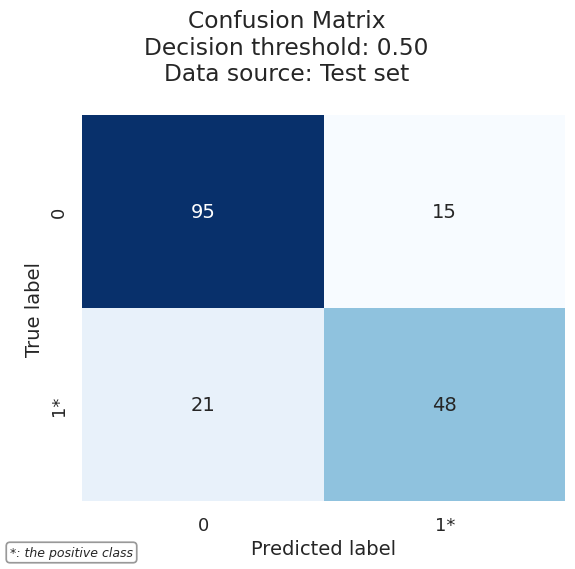

In [89]:
display(
    evaluation_report.metrics.summarize(
        data_source="both",
        metric=["accuracy", "precision", "recall", "f1", "roc_auc", "log_loss", "brier_score"],
    ).frame(favorability=True)
)
evaluation_report.metrics.confusion_matrix().plot()

In [ ]:
competition_predictions = pd.DataFrame(
    {
        "PassengerId": test_df["PassengerId"],
        "Survived": model_pipeline.predict(X_test_final),
    }
)

competition_predictions.head()